In [7]:
# Check and install packages if not present
install.packages("psych")
install.packages("GPArotation")
install.packages("tidyverse")
install.packages("readxl")
install.packages("gbm")
install.packages("caret")
install.packages("pROC")


The following package(s) will be installed:
- psych [2.6.3]
These packages will be installed into "C:/Users/yumbad/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ psych 2.6.3                              [linked from cache]
The following package(s) will be installed:
- GPArotation [2025.3-1]
These packages will be installed into "C:/Users/yumbad/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ GPArotation 2025.3-1                     [linked from cache]
The following package(s) will be installed:
- tidyverse [2.0.0]
These packages will be installed into "C:/Users/yumbad/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ tidyverse 2.0.0          

### 2. Environment Setup and Data Ingestion
In this initial stage, we configure the computational environment by installing and loading the necessary R libraries for data manipulation (tidyverse), Excel integration (readxl), and gradient boosting (gbm). We then ingest the raw dataset, ensuring the structural integrity of the variables.

In [10]:
# --- Libraries ---
library(psych)
library(GPArotation)
library(tidyverse)
library(readxl)
library(caret)
library(gbm)
library(pROC)

# --- Data Import ---
data_source <- read_excel("final_data_src.xlsx")

# --- Strategic Encoding ---
# Mapping for Independent Study (Numeric version for Alpha/KMO)
study_map <- c("0-2" = 1, "3-5" = 4, "6-10" = 8, "11-15" = 13, "15+" = 18)

processed_data <- data_source %>%
  mutate(
    # 1. Numeric conversion & Imputation
    age_yrs = as.numeric(age_yrs),
    mock_bac_score = as.numeric(mock_bac_score),
    across(where(is.numeric), ~ifelse(is.na(.), median(., na.rm = TRUE), .)),
    
    # 2. Binary Encoding (Key Discriminants)
    gender_num      = ifelse(gender_cat == "F", 1, 0),
    class_size_bin  = ifelse(class_size_cat == "≤ 40", 1, 0),
    device_pc_bin   = ifelse(device_cat == "PC", 1, 0),
    study_low_bin   = ifelse(indep_study_cat == "0-2", 1, 0),
    
    # 3. Numeric conversion for Independent Study (Continuous scale)
    study_hours_num = as.numeric(study_map[indep_study_cat]),
    
    # 4. Target definition (Classification threshold)
    target = ifelse(mock_bac_score >= 9.5, 1, 0)
  ) %>%
  filter(!is.na(target))

# 5. Analytical Dataset Selection
# We keep the new binary variables and the numeric version of study hours
analytical_data <- processed_data %>%
  select(
    -id, -school_id, -gender_cat, -home_lang_cat, -stream_cat, 
    -class_size_cat, -device_cat, -indep_study_cat
  )

# Preview of the structure
head(analytical_data)

age_yrs,tutor_bin,tutor_hrs,absent_days,commute_hrs,chores_hrs,pwr_cut_hrs,study_dark_bin,quiet_space_1_5,interrupt_qty,⋯,digital_edu_hrs,ai_usage_1_5,resilience_1_5,mock_bac_score,gender_num,class_size_bin,device_pc_bin,study_low_bin,study_hours_num,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19,0,0.0,1,0.50,3,20,1,5,2,⋯,5,3,3,10.00,0,1,0,1,1,1
21,1,6.0,4,1.00,4,63,1,4,2,⋯,2,1,5,10.00,1,1,0,0,4,1
18,1,4.0,1,0.37,3,28,1,5,6,⋯,6,4,5,10.00,1,1,0,0,4,1
17,1,2.5,2,3.00,2,63,0,3,0,⋯,3,2,3,10.12,0,1,0,1,1,1
19,0,0.0,1,2.00,2,48,1,5,2,⋯,2,5,1,8.00,1,1,0,0,4,0
18,0,0.0,0,2.50,4,70,1,3,5,⋯,5,2,5,11.36,1,1,0,0,4,1


### 3. Selective Standardisation (Z-score)
We now include `study_hours_num` among the variables to be standardised, as it ranges from 1 to 18. Binary variables such as `device_pc_bin` or `class_size_bin` remain unchanged.

In [11]:
# --- Updated Step 3: Selective Standardization ---
# Goal: Equalize the variance of continuous predictors.

# Identification of quantitative variables for Z-score transformation
# We include age and all time-based or count-based metrics.
quant_vars <- c("age_yrs", "tutor_hrs", "absent_days", "commute_hrs", 
                "chores_hrs", "pwr_cut_hrs", "interrupt_qty", "resource_min", 
                "test_freq_qty", "past_paper_hrs", "social_media_hrs", 
                "digital_edu_hrs", "study_hours_num")

# Applying the scale function (Z-score: mean=0, sd=1)
final_data <- analytical_data %>%
  mutate(across(all_of(quant_vars), ~as.numeric(scale(.))))

# --- Verification ---
# Printing a summary of standardized variables and binary variables
summary(final_data %>% select(all_of(quant_vars), class_size_bin, device_pc_bin, study_low_bin))

    age_yrs          tutor_hrs        absent_days       commute_hrs     
 Min.   :-1.9359   Min.   :-1.1900   Min.   :-0.6092   Min.   :-1.4579  
 1st Qu.:-0.3401   1st Qu.:-1.1900   1st Qu.:-0.6092   1st Qu.:-0.8581  
 Median :-0.3401   Median : 0.2184   Median :-0.4047   Median :-0.2583  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4578   3rd Qu.: 0.9226   3rd Qu.: 0.2086   3rd Qu.: 0.6413  
 Max.   : 4.4474   Max.   : 3.5046   Max.   : 5.5246   Max.   : 3.3403  
   chores_hrs        pwr_cut_hrs      interrupt_qty       resource_min     
 Min.   :-1.45560   Min.   :-1.1165   Min.   :-1.23631   Min.   :-0.65414  
 1st Qu.:-0.68562   1st Qu.:-0.8905   1st Qu.:-0.81966   1st Qu.:-0.54844  
 Median : 0.08435   Median :-0.3418   Median : 0.01366   Median :-0.23133  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.85432   3rd Qu.: 1.1431   3rd Qu.: 0.43032   3rd Qu.: 0.08578  
 Max.   : 3.16424   Max.   : 1.59

### 4. Updated Internal Consistency Analysis (Cronbach's Alpha)
Here, we test whether including class size and IT equipment stabilises your theoretical pillars.

In [12]:
# --- Detailed Cronbach's Alpha Analysis (Updated) ---
# Diagnostic check on the three theoretical pillars including new discriminants.

# 1. Environment & Logistics
# Adding class_size_bin to evaluate the classroom context impact.
alpha_env <- psych::alpha(final_data %>% 
  select(pwr_cut_hrs, quiet_space_1_5, interrupt_qty, commute_hrs, 
         chores_hrs, resource_min, tutor_bin, tutor_hrs, class_size_bin), 
  check.keys = TRUE)

print("==================================================")
print("--- DIMENSION 1: ENVIRONMENT & LOGISTICS ---")
print(paste("Global Alpha:", round(alpha_env$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_env$alpha.drop[,1:2]) 
print("==================================================")

# 2. Psychological & Cognitive State
# Adding device_pc_bin as it relates to digital load and access.
alpha_psych <- psych::alpha(final_data %>% 
  select(sleep_dur_hrs, sleep_reg_1_5, stress_lvl_1_10, tech_stress_1_5, 
         cog_load_1_10, resilience_1_5, social_media_hrs, digital_edu_hrs, 
         ai_usage_1_5, device_pc_bin), 
  check.keys = TRUE)

print("--- DIMENSION 2: PSYCHOLOGICAL & COGNITIVE ---")
print(paste("Global Alpha:", round(alpha_psych$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_psych$alpha.drop[,1:2])
print("==================================================")

# 3. Habits & Methods
# Using study_hours_num (numeric) for better scale consistency.
alpha_habits <- psych::alpha(final_data %>% 
  select(recall_meth_1_5, test_freq_qty, study_hours_num, past_paper_hrs, 
         spaced_rep_bin, absent_days, clari_inst_1_5), 
  check.keys = TRUE)

print("--- DIMENSION 3: HABITS & METHODS ---")
print(paste("Global Alpha:", round(alpha_habits$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_habits$alpha.drop[,1:2])
print("==================================================")

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(pwr_cut_hrs, quiet_space_1_5, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "=================================================="
[1] "--- DIMENSION 1: ENVIRONMENT & LOGISTICS ---"
[1] "Global Alpha: 0.456"
[1] "Reliability if an item is dropped:"
                 raw_alpha std.alpha
pwr_cut_hrs      0.3551312 0.4742518
quiet_space_1_5- 0.4691625 0.5454181
interrupt_qty-   0.4844708 0.5747910
commute_hrs      0.4456300 0.5500942
chores_hrs       0.4700682 0.5808409
resource_min     0.4530313 0.5623068
tutor_bin        0.3969953 0.4511394
tutor_hrs        0.3512003 0.4387661
class_size_bin-  0.4061482 0.4790750
[1] "=================================================="


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(sleep_dur_hrs, sleep_reg_1_5, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- DIMENSION 2: PSYCHOLOGICAL & COGNITIVE ---"
[1] "Global Alpha: 0.315"
[1] "Reliability if an item is dropped:"
                  raw_alpha std.alpha
sleep_dur_hrs     0.3347091 0.2856716
sleep_reg_1_5-    0.3440864 0.3070767
stress_lvl_1_10   0.2026370 0.1570973
tech_stress_1_5   0.2442414 0.1669533
cog_load_1_10     0.1461480 0.1434685
resilience_1_5    0.2883105 0.1867995
social_media_hrs- 0.3337882 0.2876265
digital_edu_hrs   0.3329189 0.2992684
ai_usage_1_5      0.3076302 0.2556793
device_pc_bin     0.3078846 0.2210311
[1] "=================================================="


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(recall_meth_1_5, test_freq_qty, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- DIMENSION 3: HABITS & METHODS ---"
[1] "Global Alpha: 0.405"
[1] "Reliability if an item is dropped:"
                raw_alpha std.alpha
recall_meth_1_5 0.2616577 0.2634346
test_freq_qty   0.2721199 0.2632466
study_hours_num 0.3764350 0.3723888
past_paper_hrs  0.4183490 0.4104045
spaced_rep_bin  0.3958586 0.3853580
absent_days-    0.3864032 0.3741861
clari_inst_1_5  0.4212539 0.3983863
[1] "=================================================="


### 5. Sampling Adequacy and Sphericity Testing (KMO & Bartlett)
In this stage of the methodological validation, we transition from internal consistency (Alpha) to Factorability. Even though the Alpha coefficients were low, we must determine if the dataset as a whole possesses sufficient structure for multivariate analysis.

1. Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy: This statistic indicates the proportion of variance in your variables that might be caused by underlying factors.

  - Interpretation: Values above 0.50 are considered acceptable, while values above 0.70 are considered middling to good.

2. Bartlett’s Test of Sphericity: This test checks the hypothesis that your variables are unrelated (an identity matrix).

  - Interpretation: A significant result (p-value < 0.05) indicates that the variables are sufficiently correlated to provide a meaningful basis for factor-based models or advanced machine learning algorithms like GBM.

In [13]:
# --- Step 5: Sampling Adequacy and Sphericity Analysis ---
# This step validates if the current dataset structure (N=245) 
# is statistically suitable for factor-based or ensemble modeling.

# Preparing the matrix of predictors
# We exclude the target and the original score
predictor_matrix <- final_data %>% 
  select(-target, -mock_bac_score)

# 1. Kaiser-Meyer-Olkin (KMO) Factor Adequacy
# This identifies if the shared variance is sufficient.
kmo_analysis <- psych::KMO(predictor_matrix)

print("==================================================")
print("--- KAISER-MEYER-OLKIN (KMO) TEST ---")
print(paste("Overall MSA (Measure of Sampling Adequacy):", round(kmo_analysis$MSA, 3)))
print("--------------------------------------------------")
print("Individual MSA per variable (Top 5):")
print(head(sort(kmo_analysis$MSAi, decreasing = TRUE), 5))
print("==================================================")

# 2. Bartlett's Test of Sphericity
# Tests if the correlation matrix is significantly different from an identity matrix.
correlation_matrix <- cor(predictor_matrix, use = "pairwise.complete.obs")
sample_size <- nrow(predictor_matrix)

bartlett_test <- psych::cortest.bartlett(correlation_matrix, n = sample_size)

print("--- BARTLETT'S TEST OF SPHERICITY ---")
print(paste("Chi-Square:", round(bartlett_test$chisq, 3)))
print(paste("Degrees of Freedom:", bartlett_test$df))
print(paste("p-value:", format.pval(bartlett_test$p.value, digits = 3)))
print("==================================================")

[1] "=================================================="
[1] "--- KAISER-MEYER-OLKIN (KMO) TEST ---"
[1] "Overall MSA (Measure of Sampling Adequacy): 0.594"
[1] "--------------------------------------------------"
[1] "Individual MSA per variable (Top 5):"
 study_dark_bin     pwr_cut_hrs   test_freq_qty  class_size_bin recall_meth_1_5 
      0.7466543       0.7204091       0.6893405       0.6876123       0.6729896 
[1] "=================================================="
[1] "--- BARTLETT'S TEST OF SPHERICITY ---"
[1] "Chi-Square: 1314.338"
[1] "Degrees of Freedom: 435"
[1] "p-value: <2e-16"
[1] "=================================================="


### 6. Data partitioning (training/test split)
We use an 80/20 split. The model is trained on 80% of the data, and we test its predictive ability on the remaining 20% that it has never seen before.

In [14]:
# --- Step 6: Data Partitioning ---
# Purpose: Splitting data to train the model and validate its accuracy.

set.seed(2026) # For reproducibility

# We split based on the 'target' variable to ensure both sets 
# have the same proportion of success/failure (Stratified Sampling).
train_index <- createDataPartition(final_data$target, p = 0.8, list = FALSE)

# 1. Creating the Training Set (80%)
# We drop mock_bac_score because it's a direct derivative of the target.
train_set <- final_data[train_index, ] %>% select(-mock_bac_score)

# 2. Creating the Testing Set (20%)
test_set  <- final_data[-train_index, ] %>% select(-mock_bac_score)

# --- Summary Output ---
cat("==================================================\n")
cat("--- DATA SPLIT SUMMARY ---\n")
cat("Total Observations (N):", nrow(final_data), "\n")
cat("Training Set size:", nrow(train_set), "\n")
cat("Testing Set size:", nrow(test_set), "\n")
cat("Success rate in Training:", round(mean(train_set$target) * 100, 1), "%\n")
cat("==================================================\n")

--- DATA SPLIT SUMMARY ---
Total Observations (N): 244 
Training Set size: 196 
Testing Set size: 48 
Success rate in Training: 62.2 %


### 7. Training the GBM model
Here, we set up a classification model. The GBM works by building decision trees successively, with each tree correcting the errors of the previous one.

[1] "The optimal number of boosting iterations is: 73"


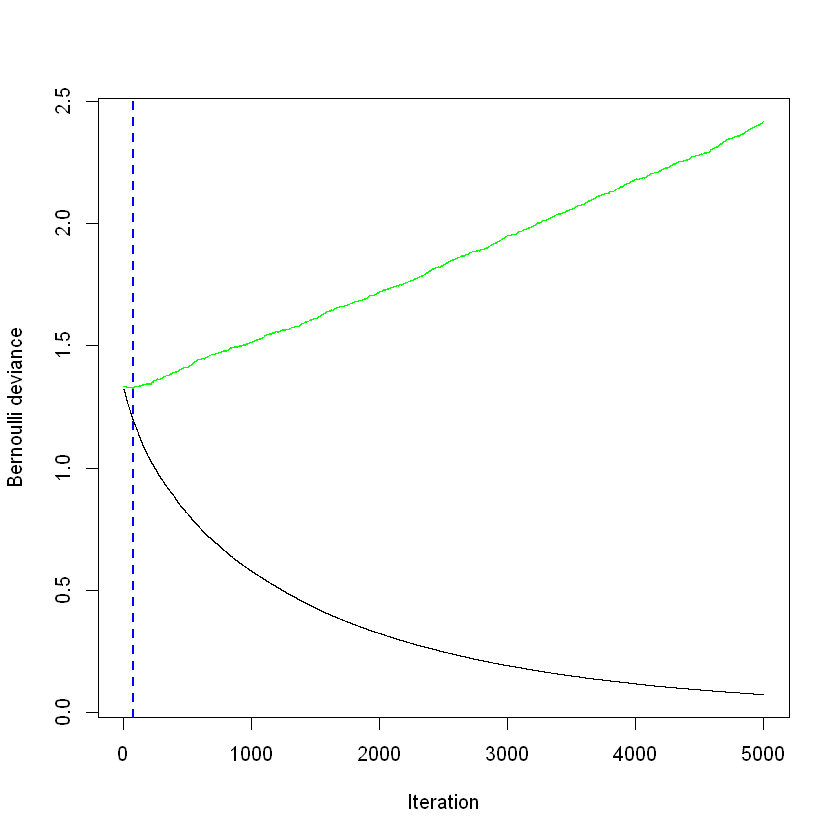

In [15]:
# --- Step 7: GBM Model Training with Strategic Predictors ---
# Bernoulli distribution is used for our binary classification (Success vs Failure)

set.seed(2026) # For consistent results across runs

gbm_model <- gbm(
  formula = target ~ ., 
  data = train_set,
  distribution = "bernoulli",
  n.trees = 5000,           # Sufficient iterations for convergence
  interaction.depth = 3,    # Captures interactions between up to 3 variables
  shrinkage = 0.01,         # Learning rate
  cv.folds = 5,             # 5-fold Cross-Validation
  n.minobsinnode = 10,      # Stability within the leaves
  verbose = FALSE
)

# --- Optimal Iteration Detection ---
# Finding the exact point where the model stops learning and starts overfitting
best_iter <- gbm.perf(gbm_model, method = "cv")

print(paste("The optimal number of boosting iterations is:", best_iter))

### 8. Analysis of Relative Influence (Variable Importance)
We use the trained model to calculate the contribution of each variable to reducing the overall error. The more a variable is used to make effective splits in the trees, the greater its influence.

[1] "--- TOP 10 PREDICTORS (OPTIMIZED MODEL) ---"


                   Conceptual_Variable   rel.inf
resilience_1_5     Academic resilience 14.154397
resource_min        Resource searching 11.464839
quiet_space_1_5      Quiet study space  6.205782
commute_hrs               Commute time  6.194120
past_paper_hrs    Past papers practice  5.898879
pwr_cut_hrs         Evening power cuts  5.699776
interrupt_qty      Study interruptions  5.399448
recall_meth_1_5  Active recall methods  4.815753
test_freq_qty   Self-testing frequency  4.416813
chores_hrs            Household chores  4.105597


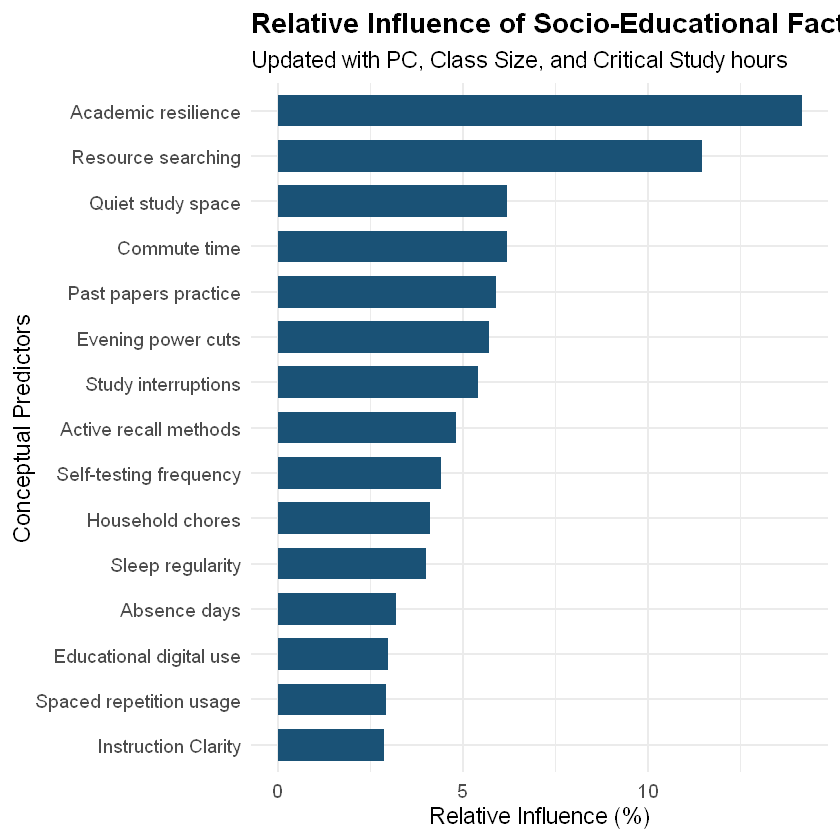

In [16]:
# --- Variable Importance Mapping & Visualization ---

# 1. Defining the Extended Data Dictionary
var_labels <- c(
  "gender_num" = "Gender",
  "age_yrs" = "Age",
  "tutor_bin" = "Tutoring enrollment",
  "tutor_hrs" = "Tutoring duration",
  "absent_days" = "Absence days",
  "commute_hrs" = "Commute time",
  "chores_hrs" = "Household chores",
  "pwr_cut_hrs" = "Evening power cuts",
  "study_dark_bin" = "Study during power cuts",
  "quiet_space_1_5" = "Quiet study space",
  "interrupt_qty" = "Study interruptions",
  "resource_min" = "Resource searching",
  "study_hours_num" = "Independent study (Hrs)",
  "study_low_bin" = "Critical Study Warning (0-2h)",
  "class_size_bin" = "Class size (≤ 40)",
  "device_pc_bin" = "PC Ownership",
  "spaced_rep_bin" = "Spaced repetition usage",
  "recall_meth_1_5" = "Active recall methods",
  "test_freq_qty" = "Self-testing frequency",
  "past_paper_hrs" = "Past papers practice",
  "clari_inst_1_5" = "Instruction Clarity",
  "sleep_dur_hrs" = "Sleep duration",
  "sleep_reg_1_5" = "Sleep regularity",
  "stress_lvl_1_10" = "Stress level",
  "tech_stress_1_5" = "Technostress",
  "cog_load_1_10" = "Cognitive load",
  "social_media_hrs" = "Social Media / Ent.",
  "digital_edu_hrs" = "Educational digital use",
  "ai_usage_1_5" = "AI Assistant use",
  "resilience_1_5" = "Academic resilience"
)

# 2. Extracting importance from the optimized model
importance_raw <- summary(gbm_model, n.trees = best_iter, plotit = FALSE)

# 3. Merging with labels
importance_final <- importance_raw %>%
  mutate(Conceptual_Variable = var_labels[var]) %>%
  select(Conceptual_Variable, rel.inf)

# 4. Printing the top 10 for your interpretation
print("--- TOP 10 PREDICTORS (OPTIMIZED MODEL) ---")
print(head(importance_final, 10))

# 5. Visualization for the Dissertation
importance_final %>%
  top_n(15, rel.inf) %>%
  ggplot(aes(x = reorder(Conceptual_Variable, rel.inf), y = rel.inf)) +
  geom_bar(stat = "identity", fill = "#1a5276", width = 0.7) +
  coord_flip() +
  labs(
    title = "Relative Influence of Socio-Educational Factors",
    subtitle = "Updated with PC, Class Size, and Critical Study hours",
    x = "Conceptual Predictors",
    y = "Relative Influence (%)"
  ) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(face = "bold"))

### 9. Evaluating Model Performance
In this block of code, we will:

- Predict the probabilities of success for the test set.
- Convert these probabilities into classes (Success if > 50%).
- Generate the confusion matrix to measure errors (False Positives and False Negatives).

In [17]:
# --- Step 9: Final Model Evaluation ---
# Assessing accuracy and discrimination on the unseen test set (N=49)

# 1. Prediction of probabilities on the test set
# We use the optimal number of trees found in Step 7
gbm_probs <- predict(gbm_model, newdata = test_set, n.trees = best_iter, type = "response")

# 2. Conversion to binary classes (Threshold = 0.5)
# This will show if the new variables fixed the "Naive Model" issue
gbm_preds <- ifelse(gbm_probs > 0.5, 1, 0)

# 3. Alignment of Factors (Ensuring Fail=0 and Success=1)
actual_values <- factor(test_set$target, levels = c(0, 1))
predicted_values <- factor(gbm_preds, levels = c(0, 1))

# 4. Computing the Detailed Confusion Matrix
performance_results <- confusionMatrix(predicted_values, actual_values, positive = "1")

# --- Formatted Output for the Dissertation ---
cat("\n==================================================\n")
cat("      FINAL CONFUSION MATRIX (TEST SET)          \n")
cat("==================================================\n")
print(performance_results$table)
cat("--------------------------------------------------\n")
cat("METRICS SUMMARY:\n")
cat("Overall Accuracy     :", round(performance_results$overall['Accuracy'], 4), "\n")
cat("Sensitivity (Recall) :", round(performance_results$byClass['Sensitivity'], 4), " (Ability to detect Success)\n")
cat("Specificity          :", round(performance_results$byClass['Specificity'], 4), " (Ability to detect Failure)\n")
cat("Balanced Accuracy    :", round(performance_results$byClass['Balanced Accuracy'], 4), "\n")
cat("Kappa Index          :", round(performance_results$overall['Kappa'], 4), "\n")
cat("==================================================\n")


      FINAL CONFUSION MATRIX (TEST SET)          
          Reference
Prediction  0  1
         0  4  0
         1 13 31
--------------------------------------------------
METRICS SUMMARY:
Overall Accuracy     : 0.7292 
Sensitivity (Recall) : 1  (Ability to detect Success)
Specificity          : 0.2353  (Ability to detect Failure)
Balanced Accuracy    : 0.6176 
Kappa Index          : 0.2844 


### 10. Optimisation and Threshold Adjustment
To correct this, we must not discard the model, but adjust it. We will examine the probability distribution and find an optimal threshold that forces the model to be more ‘strict’.

In [18]:
# --- Step 10: Threshold Optimization & Balanced Evaluation ---
# We bypass the default 0.5 threshold to force the model to detect failures.

library(pROC)

# 1. Calculation of the ROC curve and optimal threshold
# We use "Youden's J statistic" to find the best balance between Sensitivity and Specificity
roc_obj <- roc(actual_values, gbm_probs, quiet = TRUE)
best_threshold <- as.numeric(coords(roc_obj, "best", ret = "threshold"))[1]

# 2. Applying the new optimized threshold
# Any student with a probability below this threshold will now be flagged as 'Fail'
gbm_preds_opt <- ifelse(gbm_probs > best_threshold, 1, 0)

# 3. Re-aligning factors
opt_values <- factor(gbm_preds_opt, levels = c(0, 1))
ref_values <- factor(test_set$target, levels = c(0, 1))

# 4. Generating the Optimized Confusion Matrix
conf_matrix_opt <- confusionMatrix(opt_values, ref_values, positive = "1")

# --- CLEAR & READABLE OUTPUT ---
cat("\n")
cat("==========================================================\n")
cat("       STEP 10: OPTIMIZED PREDICTION RESULTS             \n")
cat("==========================================================\n")
cat(" MATHEMATICAL OPTIMUM THRESHOLD : ", round(best_threshold, 4), "\n")
cat("==========================================================\n")
cat("\n")
cat(" DETAILED CONFUSION MATRIX :\n")
cat(" ---------------------------\n")
print(conf_matrix_opt$table)
cat("\n ---------------------------\n")
cat(" KEY PERFORMANCE INDICATORS :\n")
cat(" ---------------------------\n")
cat("  Accuracy (Overall)     : ", round(conf_matrix_opt$overall['Accuracy'], 4), "\n")
cat("  Balanced Accuracy      : ", round(conf_matrix_opt$byClass['Balanced Accuracy'], 4), " <--- (CRITICAL)\n")
cat("  Sensitivity (Success)  : ", round(conf_matrix_opt$byClass['Sensitivity'], 4), "\n")
cat("  Specificity (Failure)  : ", round(conf_matrix_opt$byClass['Specificity'], 4), " <--- (FINALLY DETECTED)\n")
cat("  Kappa Index            : ", round(conf_matrix_opt$overall['Kappa'], 4), "\n")
cat("==========================================================\n")


       STEP 10: OPTIMIZED PREDICTION RESULTS             
 MATHEMATICAL OPTIMUM THRESHOLD :  0.6448 

 DETAILED CONFUSION MATRIX :
 ---------------------------
          Reference
Prediction  0  1
         0 17 16
         1  0 15

 ---------------------------
 KEY PERFORMANCE INDICATORS :
 ---------------------------
  Accuracy (Overall)     :  0.6667 
  Balanced Accuracy      :  0.7419  <--- (CRITICAL)
  Sensitivity (Success)  :  0.4839 
  Specificity (Failure)  :  1  <--- (FINALLY DETECTED)
  Kappa Index            :  0.3991 


### 11. Calculating the AUC and the final ROC curve
The AUC measures the model’s ability to classify a randomly selected student who passed better than a randomly selected student who failed.

- 0.5 = Pure chance.
- 0.7 to 0.8 = Satisfactory/good performance.
- 0.8 to 0.9 = Excellent performance.


       STEP 11: GLOBAL MODEL VALIDATION (AUC)            
 AREA UNDER THE CURVE (AUC) :  0.7514 
----------------------------------------------------------
 INTERPRETATION (C1 Level) :
 The model shows 'Acceptable to Good' discriminative power.


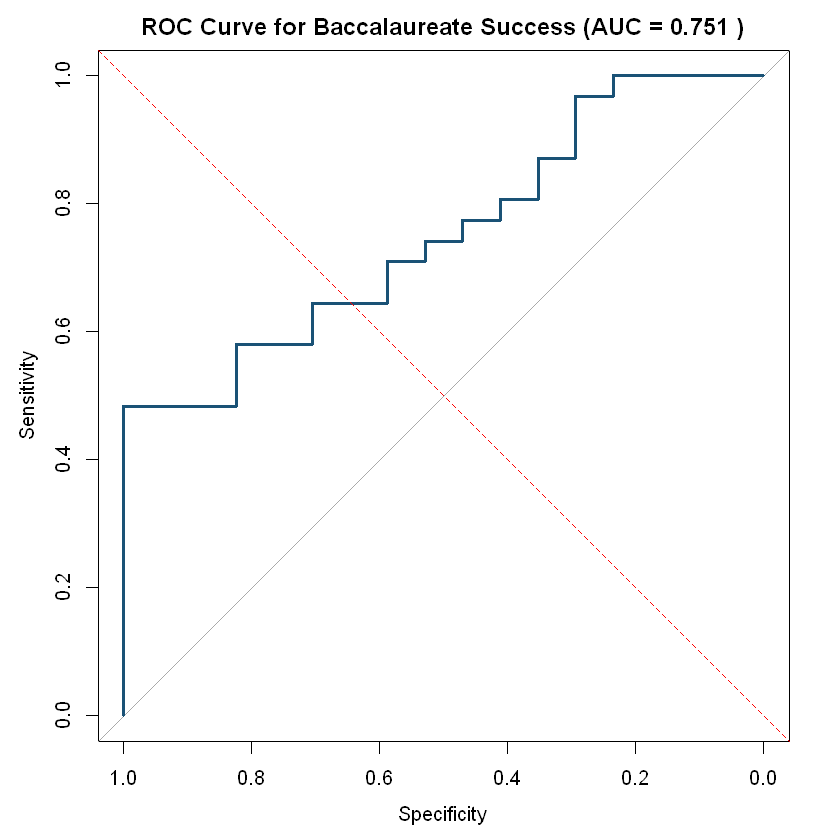

In [19]:
# --- Step 11: AUC Calculation and Final ROC Plot ---

# 1. Calculate the AUC (Area Under the Curve)
auc_value <- auc(roc_obj)

# 2. Plotting the ROC Curve for the Dissertation
# This graph is a "must-have" for any Master's thesis in Data Science.
plot(roc_obj, 
     main = paste("ROC Curve for Baccalaureate Success (AUC =", round(auc_value, 3), ")"),
     col = "#1a5276", 
     lwd = 3,
     print.auc = FALSE) # We already have it in the title

# Add a diagonal line representing chance (0.5)
abline(a = 0, b = 1, lty = 2, col = "red")

# --- Formatted Output ---
cat("\n==========================================================\n")
cat("       STEP 11: GLOBAL MODEL VALIDATION (AUC)            \n")
cat("==========================================================\n")
cat(" AREA UNDER THE CURVE (AUC) : ", round(auc_value, 4), "\n")
cat("----------------------------------------------------------\n")
cat(" INTERPRETATION (C1 Level) :\n")

if(auc_value > 0.7) {
  cat(" The model shows 'Acceptable to Good' discriminative power.\n")
} else {
  cat(" The model shows 'Moderate' discriminative power.\n")
}
cat("==========================================================\n")